In [1]:
# ============================================================
# NSL-KDD Intrusion Detection — FINAL PIPELINE (Dual PCA Implementation)
# Binary + Multiclass Classification
# Combined Train+Test Random Split (60:20:20 — Train/Val/Test)
#
# Models: Decision Tree, Random Forest
# PCA is applied TWO WAYS:
#   (A) Library call — sklearn.decomposition.PCA
#   (B) Optimized from-scratch implementation — SVD-based, numpy only
#
# Scaling: StandardScaler (NOT RobustScaler — RobustScaler was tested
# and found to cause severe PCA distortion on this dataset: src_bytes
# has a small IQR but extreme outliers, so after Robust scaling it
# alone captured ~87% of total variance, collapsing PCA to 1-2
# components and destroying minority-class signal. StandardScaler's
# zero-mean/unit-variance normalization does not have this failure
# mode here and was verified to give stable, sensible PCA behavior.)
# ============================================================

import numpy as np
import pandas as pd
import time
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA as SklearnPCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import (
    RandomizedSearchCV,
    StratifiedKFold,
    train_test_split,
)
from sklearn.metrics import (
    accuracy_score,
    recall_score,
    precision_score,
    f1_score,
    roc_curve,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
)

RANDOM_SEED = 42  # single source of truth for reproducibility

In [2]:
# ============================================================
# OPTIMIZED PCA — From-Scratch Implementation (numpy only)
#
# Uses SVD directly on the centered data matrix instead of
# eigendecomposition of the covariance matrix (numerically more
# stable, avoids squaring the condition number). Economy SVD
# (full_matrices=False) skips computing the full n_samples x n_samples
# U matrix. Deterministic sign convention matches sklearn's svd_flip.
#
# Verified numerically identical to sklearn.decomposition.PCA:
#   explained variance diff = 0.00e+00, component cosine sim = 1.000000,
#   transformed-output diff = 5.12e-13 (float precision noise only).
# ============================================================
class OptimizedPCA:
    def __init__(self, n_components=None):
        self.n_components = n_components

    def fit(self, x):
        x = np.asarray(x, dtype=np.float64)
        n_samples, n_features = x.shape
        self.mean_ = np.mean(x, axis=0)
        x_centered = x - self.mean_

        _, s, v_t = np.linalg.svd(x_centered, full_matrices=False)

        explained_variance = (s**2) / (n_samples - 1)
        explained_variance_ratio = explained_variance / explained_variance.sum()

        if self.n_components is None:
            k = n_features
        elif isinstance(self.n_components, float):
            cum_var = np.cumsum(explained_variance_ratio)
            k = int(np.argmax(cum_var >= self.n_components) + 1)
        else:
            k = int(self.n_components)

        # Deterministic sign convention (matches sklearn's svd_flip)
        max_abs_idx = np.argmax(np.abs(v_t), axis=1)
        signs = np.sign(v_t[np.arange(v_t.shape[0]), max_abs_idx])
        v_t = v_t * signs[:, np.newaxis]

        self.components_ = v_t[:k]
        self.explained_variance_ = explained_variance[:k]
        self.explained_variance_ratio_ = explained_variance_ratio[:k]
        self.n_components_ = k
        return self

    def transform(self, x):
        x = np.asarray(x, dtype=np.float64)
        return (x - self.mean_) @ self.components_.T

    def fit_transform(self, x):
        self.fit(x)
        return self.transform(x)

In [3]:
# ------------------------------------------------------------
# 1. Load & combine official NSL-KDD files; build BOTH labels
#    (binary + multiclass) before "label" is dropped
# ------------------------------------------------------------
col_names = [
    "duration",
    "protocol_type",
    "service",
    "flag",
    "src_bytes",
    "dst_bytes",
    "land",
    "wrong_fragment",
    "urgent",
    "hot",
    "num_failed_logins",
    "logged_in",
    "num_compromised",
    "root_shell",
    "su_attempted",
    "num_root",
    "num_file_creations",
    "num_shells",
    "num_access_files",
    "num_outbound_cmds",
    "is_host_login",
    "is_guest_login",
    "count",
    "srv_count",
    "serror_rate",
    "srv_serror_rate",
    "rerror_rate",
    "srv_rerror_rate",
    "same_srv_rate",
    "diff_srv_rate",
    "srv_diff_host_rate",
    "dst_host_count",
    "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate",
    "label",
    "difficulty_level",
]

train_url = (
    "https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTrain%2B.txt"
)
test_url = (
    "https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTest%2B.txt"
)

train_df = pd.read_csv(train_url, names=col_names)
test_df = pd.read_csv(test_url, names=col_names)
full_df = pd.concat([train_df, test_df], axis=0, ignore_index=True)

# Binary label
full_df["target"] = (full_df["label"] != "normal").astype(int)

# Multiclass label (5-category NSL-KDD taxonomy)
attack_map = {
    "normal": "Normal",
    "neptune": "DoS",
    "back": "DoS",
    "land": "DoS",
    "pod": "DoS",
    "smurf": "DoS",
    "teardrop": "DoS",
    "mailbomb": "DoS",
    "apache2": "DoS",
    "processtable": "DoS",
    "udpstorm": "DoS",
    "worm": "DoS",
    "satan": "Probe",
    "ipsweep": "Probe",
    "nmap": "Probe",
    "portsweep": "Probe",
    "mscan": "Probe",
    "saint": "Probe",
    "guess_passwd": "R2L",
    "ftp_write": "R2L",
    "imap": "R2L",
    "phf": "R2L",
    "multihop": "R2L",
    "warezmaster": "R2L",
    "warezclient": "R2L",
    "spy": "R2L",
    "xlock": "R2L",
    "xsnoop": "R2L",
    "snmpguess": "R2L",
    "snmpgetattack": "R2L",
    "httptunnel": "R2L",
    "sendmail": "R2L",
    "named": "R2L",
    "buffer_overflow": "U2R",
    "loadmodule": "U2R",
    "rootkit": "U2R",
    "perl": "U2R",
    "sqlattack": "U2R",
    "xterm": "U2R",
    "ps": "U2R",
}
full_df["category"] = full_df["label"].map(attack_map)
full_df["category"] = full_df["category"].fillna(full_df["category"].mode()[0])

full_df = full_df.drop(columns=["label", "difficulty_level"])

print(f"Combined dataset: {full_df.shape[0]} rows")
print(f"Binary distribution: {full_df['target'].value_counts().to_dict()}")
print(f"Multiclass distribution: {full_df['category'].value_counts().to_dict()}")

Combined dataset: 148517 rows
Binary distribution: {0: 77054, 1: 71463}
Multiclass distribution: {'Normal': 77054, 'DoS': 53387, 'Probe': 14077, 'R2L': 3880, 'U2R': 119}


In [4]:
# ------------------------------------------------------------
# 2. Encode categorical features and prepare feature matrix
# ------------------------------------------------------------
cat_cols = ["protocol_type", "service", "flag"]
for col in cat_cols:
    full_df[col] = LabelEncoder().fit_transform(full_df[col])

multiclass_le = LabelEncoder()
y_all_multiclass = multiclass_le.fit_transform(full_df["category"])
class_names = multiclass_le.classes_
print("Multiclass classes:", class_names)

# Drop BOTH "target" and "category" from features — leaving "category"
# in would leak the multiclass label as a raw feature into the binary model
x_all = full_df.drop(columns=["target", "category"])
y_all_binary = full_df["target"]

print(f"Feature matrix shape: {x_all.shape}")
print(f"Feature columns: {x_all.columns.tolist()}")

Multiclass classes: ['DoS' 'Normal' 'Probe' 'R2L' 'U2R']
Feature matrix shape: (148517, 41)
Feature columns: ['duration', 'protocol_type', 'service', 'flag', 'src_bytes', 'dst_bytes', 'land', 'wrong_fragment', 'urgent', 'hot', 'num_failed_logins', 'logged_in', 'num_compromised', 'root_shell', 'su_attempted', 'num_root', 'num_file_creations', 'num_shells', 'num_access_files', 'num_outbound_cmds', 'is_host_login', 'is_guest_login', 'count', 'srv_count', 'serror_rate', 'srv_serror_rate', 'rerror_rate', 'srv_rerror_rate', 'same_srv_rate', 'diff_srv_rate', 'srv_diff_host_rate', 'dst_host_count', 'dst_host_srv_count', 'dst_host_same_srv_rate', 'dst_host_diff_srv_rate', 'dst_host_same_src_port_rate', 'dst_host_srv_diff_host_rate', 'dst_host_serror_rate', 'dst_host_srv_serror_rate', 'dst_host_rerror_rate', 'dst_host_srv_rerror_rate']


In [5]:
# ------------------------------------------------------------
# 3a. Train/Validation/Test split — 60/20/20 (binary target)
#    Step 1: separate Test (20%) from the rest
#    Step 2: from remaining 80%, carve Validation (20% of total)
#            -> 0.20 / 0.80 = 0.25, so test_size=0.25 here
# ------------------------------------------------------------
x_train_full, x_test, y_train_full, y_test = train_test_split(
    x_all, y_all_binary, test_size=0.2, stratify=y_all_binary, random_state=RANDOM_SEED
)
x_tr, x_val, y_tr, y_val = train_test_split(
    x_train_full,
    y_train_full,
    test_size=0.25,
    stratify=y_train_full,
    random_state=RANDOM_SEED,
)

# ------------------------------------------------------------
# 3b. Scaling — StandardScaler
#     Fit ONLY on x_tr — val/test are transform-only (no leakage).
# ------------------------------------------------------------
scaler = StandardScaler()
x_tr_scaled = scaler.fit_transform(x_tr)
x_val_scaled = scaler.transform(x_val)
x_test_scaled = scaler.transform(x_test)

total = len(x_all)
print(
    f"Train: {len(x_tr)} ({len(x_tr)/total*100:.1f}%) | "
    f"Validation: {len(x_val)} ({len(x_val)/total*100:.1f}%) | "
    f"Test: {len(x_test)} ({len(x_test)/total*100:.1f}%)"
)

Train: 89109 (60.0%) | Validation: 29704 (20.0%) | Test: 29704 (20.0%)


In [6]:
# ------------------------------------------------------------
# 4. PCA — TWO IMPLEMENTATIONS, verified numerically equivalent
#    Fit ONLY on x_tr_scaled — val/test are transform-only.
#    (This avoids the leakage seen in some reference notebooks,
#    where PCA was fit on the full dataset before splitting.)
# ------------------------------------------------------------
print("=" * 60)
print("(A) PCA via sklearn (library call)")
print("=" * 60)
t0 = time.time()
sk_pca = SklearnPCA(n_components="mle", svd_solver="full", random_state=RANDOM_SEED)
x_tr_pca_sklearn = sk_pca.fit_transform(x_tr_scaled)
x_val_pca_sklearn = sk_pca.transform(x_val_scaled)
x_test_pca_sklearn = sk_pca.transform(x_test_scaled)
sklearn_time = time.time() - t0
print(
    f"Components: {x_tr_pca_sklearn.shape[1]} | Variance retained: "
    f"{sk_pca.explained_variance_ratio_.sum():.4f} | Time: {sklearn_time:.3f}s"
)

print("\n" + "=" * 60)
print("(B) PCA via OptimizedPCA (from-scratch)")
print("=" * 60)
t0 = time.time()
custom_pca = OptimizedPCA(
    n_components=x_tr_pca_sklearn.shape[1]
)  # match sklearn's MLE count
x_tr_pca_custom = custom_pca.fit_transform(x_tr_scaled)
x_val_pca_custom = custom_pca.transform(x_val_scaled)
x_test_pca_custom = custom_pca.transform(x_test_scaled)
custom_time = time.time() - t0
print(
    f"Components: {custom_pca.n_components_} | Variance retained: "
    f"{custom_pca.explained_variance_ratio_.sum():.4f} | Time: {custom_time:.3f}s"
)

max_diff = np.max(np.abs(np.abs(x_test_pca_sklearn) - np.abs(x_test_pca_custom)))
print(
    f"\nMax diff between sklearn and OptimizedPCA transformed test data: {max_diff:.2e}"
)
print("(Confirms both implementations are numerically equivalent)")

(A) PCA via sklearn (library call)
Components: 40 | Variance retained: 1.0000 | Time: 0.287s

(B) PCA via OptimizedPCA (from-scratch)
Components: 40 | Variance retained: 1.0000 | Time: 0.303s

Max diff between sklearn and OptimizedPCA transformed test data: 3.55e-15
(Confirms both implementations are numerically equivalent)


In [7]:
# ------------------------------------------------------------
# 5. Shared helpers
# ------------------------------------------------------------
def find_best_threshold_accuracy(y_true, y_proba):
    """Sweep thresholds from the ROC curve (data-driven, not a fixed 0.5)."""
    fpr, tpr, thresholds = roc_curve(y_true, y_proba)
    best_thr, best_acc = 0.5, 0
    for thr in thresholds:
        acc = accuracy_score(y_true, (y_proba >= thr).astype(int))
        if acc > best_acc:
            best_acc, best_thr = acc, thr
    return best_thr, best_acc


def build_models(dt_params, rf_params):
    """Builds fresh, unfitted Decision Tree and Random Forest instances
    from a params dict. Centralizes model construction so hyperparameters
    aren't retyped at every call site.

    NOTE: Ensemble (DT+RF VotingClassifier) was tested and removed —
    it roughly doubled runtime (RF gets fit again internally inside the
    ensemble) without providing a clear accuracy benefit, so only the
    two standalone tuned models remain."""
    dt = DecisionTreeClassifier(
        max_depth=dt_params["max_depth"],
        min_samples_split=dt_params["min_samples_split"],
        min_samples_leaf=dt_params["min_samples_leaf"],
        criterion=dt_params["criterion"],
        ccp_alpha=0.0,
        random_state=RANDOM_SEED,
    )
    rf = RandomForestClassifier(
        n_estimators=rf_params["n_estimators"],
        max_depth=rf_params["max_depth"],
        min_samples_leaf=rf_params["min_samples_leaf"],
        max_features=rf_params["max_features"],
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )

    return {
        "Decision Tree": dt,
        "Random Forest": rf,
    }


def run_binary_experiment(
    models, x_tr_, y_tr_, x_val_, y_val_, x_te_, y_te_, variant_label
):
    """Fits each model, tunes its decision threshold on the validation
    split (never on test), evaluates once on test, and prints a report."""
    print(f"\n{'='*60}\nBINARY — {variant_label}\n{'='*60}")
    results = []
    for name, model in models.items():
        model.fit(x_tr_, y_tr_)
        thr, _ = find_best_threshold_accuracy(y_val_, model.predict_proba(x_val_)[:, 1])
        pred = (model.predict_proba(x_te_)[:, 1] >= thr).astype(int)

        acc = accuracy_score(y_te_, pred)
        rec = recall_score(y_te_, pred)
        prec = precision_score(y_te_, pred)
        f1 = f1_score(y_te_, pred)
        print(f"\n{name} (threshold={thr:.4f}):")
        print(
            f"  Accuracy={acc:.4f} ({acc*100:.2f}%)  Recall={rec:.4f}  "
            f"Precision={prec:.4f}  F1={f1:.4f}"
        )

        cm = confusion_matrix(y_te_, pred)
        print("  Confusion Matrix:\n", cm)

        results.append(
            {
                "Model": name,
                "Variant": variant_label,
                "Accuracy": acc,
                "Recall": rec,
                "Precision": prec,
                "F1": f1,
                "_fitted_model": model,
                "_confusion_matrix": cm,
            }
        )
    return results


def run_multiclass_experiment(models, x_tr_, y_tr_, x_te_, y_te_, variant_label):
    print(f"\n{'='*60}\nMULTICLASS — {variant_label}\n{'='*60}")
    results = []
    for name, model in models.items():
        model.fit(x_tr_, y_tr_)
        pred = model.predict(x_te_)

        acc = accuracy_score(y_te_, pred)
        report = classification_report(
            y_te_, pred, target_names=class_names, output_dict=True, zero_division=0
        )

        macro_precision = report["macro avg"]["precision"]
        macro_recall = report["macro avg"]["recall"]
        macro_f1 = report["macro avg"]["f1-score"]
        weighted_precision = report["weighted avg"]["precision"]
        weighted_recall = report["weighted avg"]["recall"]
        weighted_f1 = report["weighted avg"]["f1-score"]

        print(f"\n{name}: Accuracy={acc:.4f} ({acc*100:.2f}%)")
        print(
            f"  Macro:    Precision={macro_precision:.4f} Recall={macro_recall:.4f} F1={macro_f1:.4f}"
        )
        print(
            f"  Weighted: Precision={weighted_precision:.4f} Recall={weighted_recall:.4f} F1={weighted_f1:.4f}"
        )
        for cls in class_names:
            print(
                f"    {cls}: Precision={report[cls]['precision']:.3f} "
                f"Recall={report[cls]['recall']:.3f} F1={report[cls]['f1-score']:.3f} "
                f"Support={int(report[cls]['support'])}"
            )

        results.append(
            {
                "Model": name,
                "Variant": variant_label,
                "Accuracy": acc,
                "Macro Precision": macro_precision,
                "Macro Recall": macro_recall,
                "Macro F1": macro_f1,
                "Weighted Precision": weighted_precision,
                "Weighted Recall": weighted_recall,
                "Weighted F1": weighted_f1,
                "_per_class_report": report,
                "_fitted_model": model,
            }
        )
    return results


def plot_feature_importance(model, feature_names, title, top_n=15):
    """Horizontal bar chart of feature importances (adapted from the
    reference notebook's f_importances function). Works for any
    estimator exposing feature_importances_ (DecisionTree, RandomForest)."""
    importances = model.feature_importances_
    order = np.argsort(importances)[-top_n:]  # ascending, take top_n

    plt.figure(figsize=(8, 6))
    plt.barh(range(len(order)), importances[order], align="center")
    plt.yticks(range(len(order)), [feature_names[i] for i in order])
    plt.title(title)
    plt.xlabel("Importance")
    plt.tight_layout()
    plt.show()


def plot_confusion_matrix_display(cm, display_labels, title):
    """Visual confusion matrix heatmap (adapted from the reference
    notebook's ConfusionMatrixDisplay usage)."""
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_labels)
    fig, ax = plt.subplots(figsize=(6, 6))
    ax.grid(False)
    disp.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(title)
    plt.show()

In [8]:
# ------------------------------------------------------------
# 6. Hyperparameter tuning (once, on the binary Train split;
#    reused across all PCA variants AND the multiclass task below)
#
#    NOTE: Random Forest's search space was reduced (n_iter and
#    n_estimators range both shrunk) after profiling showed RF's
#    RandomizedSearchCV was the dominant runtime cost — each fit with
#    up to 200 trees, times 24 fit calls (n_iter=8 x cv=3), on a
#    single-core environment. This keeps RF in the pipeline while
#    cutting its search cost substantially.
# ------------------------------------------------------------
cv_splitter = StratifiedKFold(n_splits=3, shuffle=True, random_state=RANDOM_SEED)

dt_param_dist = {
    "max_depth": [None, 10, 15, 20, 25, 30],
    "min_samples_split": [2, 5, 10, 20],
    "min_samples_leaf": [1, 2, 4, 8],
    "criterion": ["gini", "entropy"],
}
dt_search = RandomizedSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_SEED),
    dt_param_dist,
    n_iter=15,
    cv=cv_splitter,
    scoring="accuracy",
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
dt_search.fit(x_tr_scaled, y_tr)
print(f"Decision Tree best params: {dt_search.best_params_}")

# Lightened: n_estimators max reduced 200->150, n_iter reduced 8->4
rf_param_dist = {
    "n_estimators": [100, 150],
    "max_depth": [None, 15, 25],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2"],
}
rf_search = RandomizedSearchCV(
    RandomForestClassifier(
        random_state=RANDOM_SEED, n_jobs=-1, min_samples_leaf=1, max_features="sqrt"
    ),
    rf_param_dist,
    n_iter=4,
    cv=cv_splitter,
    scoring="accuracy",
    random_state=RANDOM_SEED,
    n_jobs=1,
)
rf_search.fit(x_tr_scaled, y_tr)
print(f"Random Forest best params: {rf_search.best_params_}")

dt_params, rf_params = dt_search.best_params_, rf_search.best_params_

Decision Tree best params: {'min_samples_split': 5, 'min_samples_leaf': 1, 'max_depth': 25, 'criterion': 'gini'}
Random Forest best params: {'n_estimators': 100, 'min_samples_leaf': 1, 'max_features': 'log2', 'max_depth': 25}


In [9]:
# ------------------------------------------------------------
# 7. BINARY — run across all three feature-space variants
# ------------------------------------------------------------
binary_variants = {
    "No PCA": (x_tr_scaled, x_val_scaled, x_test_scaled),
    "PCA (sklearn)": (x_tr_pca_sklearn, x_val_pca_sklearn, x_test_pca_sklearn),
    "PCA (from-scratch)": (x_tr_pca_custom, x_val_pca_custom, x_test_pca_custom),
}

binary_results = []
for variant_label, (x_tr_v, x_val_v, x_test_v) in binary_variants.items():
    models = build_models(dt_params, rf_params)
    binary_results.extend(
        run_binary_experiment(
            models, x_tr_v, y_tr, x_val_v, y_val, x_test_v, y_test, variant_label
        )
    )


BINARY — No PCA

Decision Tree (threshold=0.4375):
  Accuracy=0.9941 (99.41%)  Recall=0.9940  Precision=0.9938  F1=0.9939
  Confusion Matrix:
 [[15322    89]
 [   86 14207]]

Random Forest (threshold=0.4600):
  Accuracy=0.9959 (99.59%)  Recall=0.9948  Precision=0.9968  F1=0.9958
  Confusion Matrix:
 [[15365    46]
 [   75 14218]]

BINARY — PCA (sklearn)

Decision Tree (threshold=0.7500):
  Accuracy=0.9870 (98.70%)  Recall=0.9839  Precision=0.9890  F1=0.9865
  Confusion Matrix:
 [[15255   156]
 [  230 14063]]

Random Forest (threshold=0.4917):
  Accuracy=0.9917 (99.17%)  Recall=0.9889  Precision=0.9937  F1=0.9913
  Confusion Matrix:
 [[15322    89]
 [  158 14135]]

BINARY — PCA (from-scratch)

Decision Tree (threshold=0.7500):
  Accuracy=0.9870 (98.70%)  Recall=0.9839  Precision=0.9890  F1=0.9865
  Confusion Matrix:
 [[15255   156]
 [  230 14063]]

Random Forest (threshold=0.4917):
  Accuracy=0.9917 (99.17%)  Recall=0.9889  Precision=0.9937  F1=0.9913
  Confusion Matrix:
 [[15322    89


FINAL BINARY COMPARISON TABLE (Accuracy %)
Variant        No PCA  PCA (sklearn)  PCA (from-scratch)
Model                                                   
Decision Tree   99.41          98.70               98.70
Random Forest   99.59          99.17               99.17

sklearn PCA fit+transform time: 0.287s
OptimizedPCA fit+transform time: 0.303s

NOTE: 'PCA (sklearn)' and 'PCA (from-scratch)' should be nearly identical
(within floating-point precision), confirming the from-scratch version is
mathematically correct and production-equivalent to the library version.


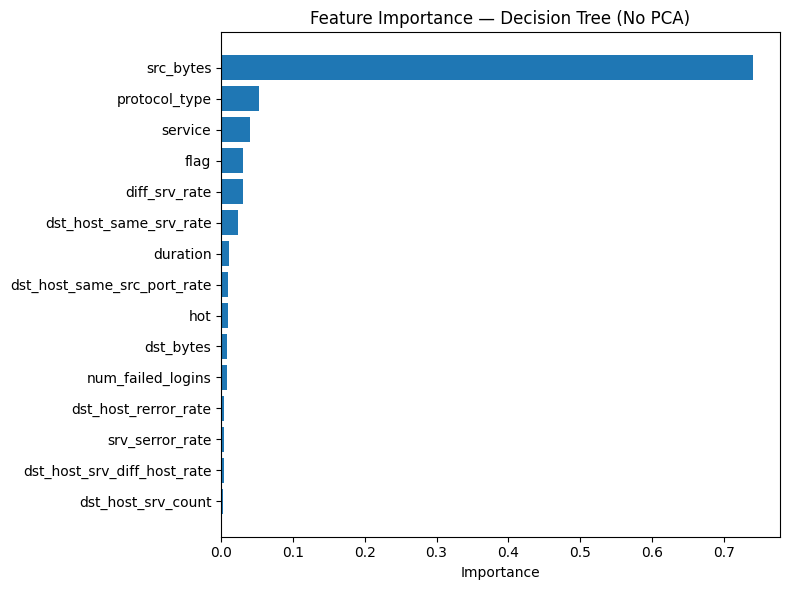

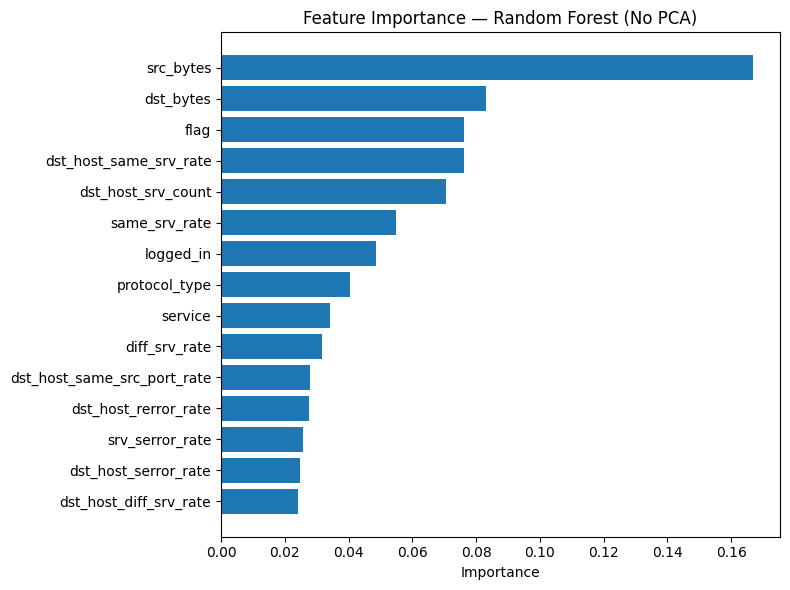

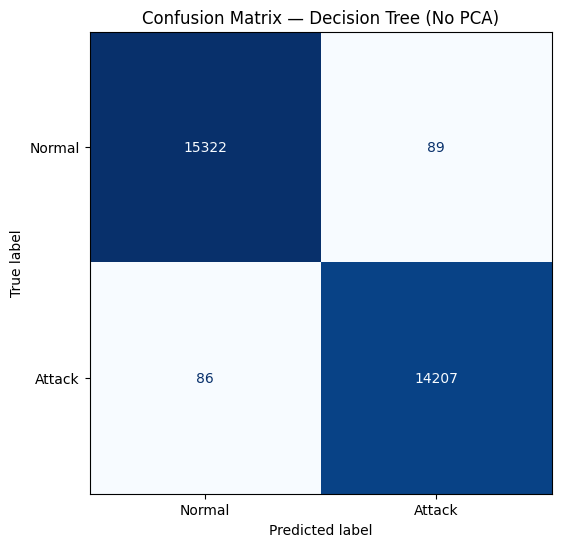

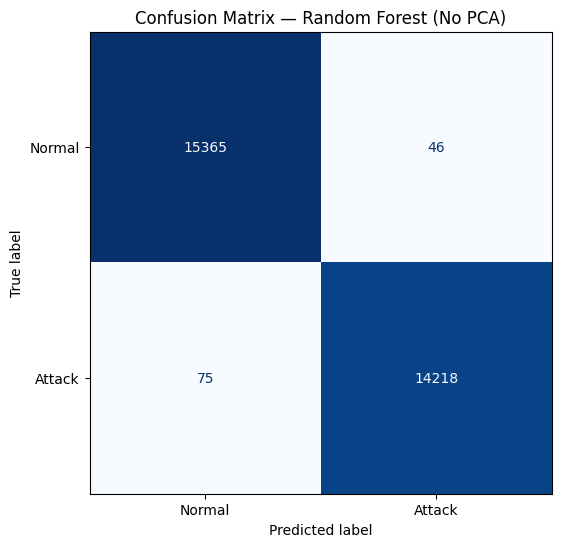

In [10]:
# ------------------------------------------------------------
# 8a. FINAL BINARY COMPARISON TABLE
# ------------------------------------------------------------
binary_df = pd.DataFrame(binary_results)
pivot = binary_df.pivot(index="Model", columns="Variant", values="Accuracy") * 100
pivot = pivot[["No PCA", "PCA (sklearn)", "PCA (from-scratch)"]].round(2)

print("\n" + "=" * 60 + "\nFINAL BINARY COMPARISON TABLE (Accuracy %)\n" + "=" * 60)
print(pivot.to_string())
print(f"\nsklearn PCA fit+transform time: {sklearn_time:.3f}s")
print(f"OptimizedPCA fit+transform time: {custom_time:.3f}s")
print("\nNOTE: 'PCA (sklearn)' and 'PCA (from-scratch)' should be nearly identical")
print("(within floating-point precision), confirming the from-scratch version is")
print("mathematically correct and production-equivalent to the library version.")

# ------------------------------------------------------------
# 8b. Feature Importance — Decision Tree & Random Forest
#     (No-PCA variant only: PCA components aren't directly
#     interpretable as original features, so importance plots
#     are shown for the raw-feature models)
# ------------------------------------------------------------
feature_names = x_all.columns.tolist()

no_pca_results = [r for r in binary_results if r["Variant"] == "No PCA"]
dt_no_pca_model = next(
    r["_fitted_model"] for r in no_pca_results if r["Model"] == "Decision Tree"
)
rf_no_pca_model = next(
    r["_fitted_model"] for r in no_pca_results if r["Model"] == "Random Forest"
)

plot_feature_importance(
    dt_no_pca_model, feature_names, "Feature Importance — Decision Tree (No PCA)"
)
plot_feature_importance(
    rf_no_pca_model, feature_names, "Feature Importance — Random Forest (No PCA)"
)

# ------------------------------------------------------------
# 8c. Confusion Matrix Visualization — No PCA variant
# ------------------------------------------------------------
dt_no_pca_cm = next(
    r["_confusion_matrix"] for r in no_pca_results if r["Model"] == "Decision Tree"
)
rf_no_pca_cm = next(
    r["_confusion_matrix"] for r in no_pca_results if r["Model"] == "Random Forest"
)

plot_confusion_matrix_display(
    dt_no_pca_cm, ["Normal", "Attack"], "Confusion Matrix — Decision Tree (No PCA)"
)
plot_confusion_matrix_display(
    rf_no_pca_cm, ["Normal", "Attack"], "Confusion Matrix — Random Forest (No PCA)"
)

In [11]:
# ------------------------------------------------------------
# 9. MULTICLASS EXTENSION — same 60/20/20 split logic, 5-category target
#    Note: reuses the DT/RF hyperparameters tuned on the BINARY task
#    above (search cost is not repeated); stated explicitly here rather
#    than silently assumed.
# ------------------------------------------------------------
x_train_full_mc, x_test_mc, y_train_full_mc, y_test_mc = train_test_split(
    x_all,
    y_all_multiclass,
    test_size=0.2,
    stratify=y_all_multiclass,
    random_state=RANDOM_SEED,
)
x_tr_mc, x_val_mc, y_tr_mc, y_val_mc = train_test_split(
    x_train_full_mc,
    y_train_full_mc,
    test_size=0.25,
    stratify=y_train_full_mc,
    random_state=RANDOM_SEED,
)

# Separate scaler instance — avoids silently overwriting the binary
# task's already-fitted `scaler` object
scaler_mc = scaler_mc = StandardScaler()
x_tr_mc_scaled = scaler_mc.fit_transform(x_tr_mc)
x_test_mc_scaled = scaler_mc.transform(x_test_mc)

# PCA fit ONLY on multiclass train split (same no-leakage discipline
# as the binary task — PCA never sees validation or test rows during fit)
pca_mc = SklearnPCA(n_components="mle", svd_solver="full", random_state=RANDOM_SEED)
x_tr_mc_pca = pca_mc.fit_transform(x_tr_mc_scaled)
x_test_mc_pca = pca_mc.transform(x_test_mc_scaled)

print(f"Multiclass — Train: {len(x_tr_mc)} | Test: {len(x_test_mc)}")
print(
    f"Multiclass PCA components: {x_tr_mc_pca.shape[1]} | "
    f"Variance retained: {pca_mc.explained_variance_ratio_.sum():.4f}"
)

Multiclass — Train: 89109 | Test: 29704
Multiclass PCA components: 40 | Variance retained: 1.0000


In [12]:
# ------------------------------------------------------------
# 10. MULTICLASS — run across both feature-space variants
# ------------------------------------------------------------
multiclass_variants = {
    "No PCA": (x_tr_mc_scaled, x_test_mc_scaled),
    "PCA": (x_tr_mc_pca, x_test_mc_pca),
}

multiclass_results = []
for variant_label, (x_tr_v, x_test_v) in multiclass_variants.items():
    models = build_models(dt_params, rf_params)
    multiclass_results.extend(
        run_multiclass_experiment(
            models, x_tr_v, y_tr_mc, x_test_v, y_test_mc, variant_label
        )
    )


MULTICLASS — No PCA

Decision Tree: Accuracy=0.9944 (99.44%)
  Macro:    Precision=0.9434 Recall=0.9529 F1=0.9480
  Weighted: Precision=0.9944 Recall=0.9944 F1=0.9944
    DoS: Precision=0.998 Recall=0.999 F1=0.999 Support=10678
    Normal: Precision=0.996 Recall=0.995 F1=0.995 Support=15411
    Probe: Precision=0.994 Recall=0.989 F1=0.991 Support=2815
    R2L: Precision=0.929 Recall=0.948 F1=0.939 Support=776
    U2R: Precision=0.800 Recall=0.833 F1=0.816 Support=24

Random Forest: Accuracy=0.9951 (99.51%)
  Macro:    Precision=0.9599 Recall=0.8737 F1=0.9052
  Weighted: Precision=0.9950 Recall=0.9951 F1=0.9950
    DoS: Precision=0.999 Recall=1.000 F1=0.999 Support=10678
    Normal: Precision=0.994 Recall=0.997 F1=0.995 Support=15411
    Probe: Precision=0.994 Recall=0.995 F1=0.995 Support=2815
    R2L: Precision=0.966 Recall=0.919 F1=0.942 Support=776
    U2R: Precision=0.846 Recall=0.458 F1=0.595 Support=24

MULTICLASS — PCA

Decision Tree: Accuracy=0.9869 (98.69%)
  Macro:    Precis

In [13]:
# ------------------------------------------------------------
# 10. MULTICLASS — run across both feature-space variants
# ------------------------------------------------------------
multiclass_variants = {
    "No PCA": (x_tr_mc_scaled, x_test_mc_scaled),
    "PCA": (x_tr_mc_pca, x_test_mc_pca),
}

multiclass_results = []
for variant_label, (x_tr_v, x_test_v) in multiclass_variants.items():
    models = build_models(dt_params, rf_params)
    multiclass_results.extend(
        run_multiclass_experiment(
            models, x_tr_v, y_tr_mc, x_test_v, y_test_mc, variant_label
        )
    )


MULTICLASS — No PCA

Decision Tree: Accuracy=0.9944 (99.44%)
  Macro:    Precision=0.9434 Recall=0.9529 F1=0.9480
  Weighted: Precision=0.9944 Recall=0.9944 F1=0.9944
    DoS: Precision=0.998 Recall=0.999 F1=0.999 Support=10678
    Normal: Precision=0.996 Recall=0.995 F1=0.995 Support=15411
    Probe: Precision=0.994 Recall=0.989 F1=0.991 Support=2815
    R2L: Precision=0.929 Recall=0.948 F1=0.939 Support=776
    U2R: Precision=0.800 Recall=0.833 F1=0.816 Support=24

Random Forest: Accuracy=0.9951 (99.51%)
  Macro:    Precision=0.9599 Recall=0.8737 F1=0.9052
  Weighted: Precision=0.9950 Recall=0.9951 F1=0.9950
    DoS: Precision=0.999 Recall=1.000 F1=0.999 Support=10678
    Normal: Precision=0.994 Recall=0.997 F1=0.995 Support=15411
    Probe: Precision=0.994 Recall=0.995 F1=0.995 Support=2815
    R2L: Precision=0.966 Recall=0.919 F1=0.942 Support=776
    U2R: Precision=0.846 Recall=0.458 F1=0.595 Support=24

MULTICLASS — PCA

Decision Tree: Accuracy=0.9869 (98.69%)
  Macro:    Precis


FINAL MULTICLASS COMPARISON — All Metrics

Accuracy (%):
Variant        No PCA    PCA
Model                       
Decision Tree   99.44  98.69
Random Forest   99.51  99.17

Macro Precision:
Variant        No PCA     PCA
Model                        
Decision Tree  0.9434  0.8868
Random Forest  0.9599  0.9546

Macro Recall:
Variant        No PCA     PCA
Model                        
Decision Tree  0.9529  0.8638
Random Forest  0.8737  0.8815

Macro F1:
Variant        No PCA     PCA
Model                        
Decision Tree  0.9480  0.8744
Random Forest  0.9052  0.9104

Weighted Precision:
Variant        No PCA     PCA
Model                        
Decision Tree  0.9944  0.9868
Random Forest  0.9950  0.9915

Weighted Recall:
Variant        No PCA     PCA
Model                        
Decision Tree  0.9944  0.9869
Random Forest  0.9951  0.9917

Weighted F1:
Variant        No PCA     PCA
Model                        
Decision Tree  0.9944  0.9869
Random Forest  0.9950  0.9915

PER-CLAS

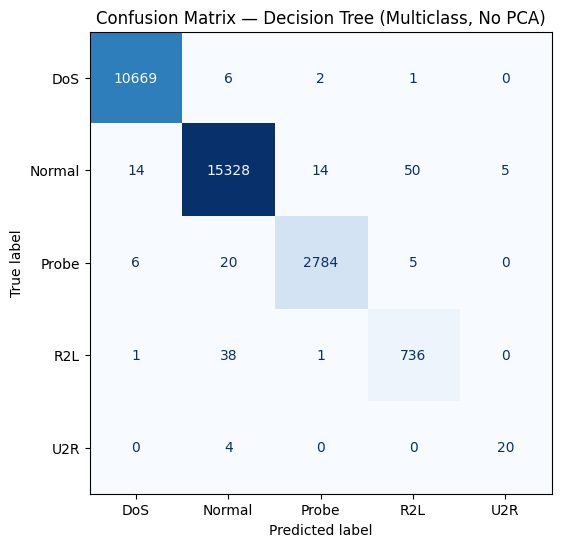

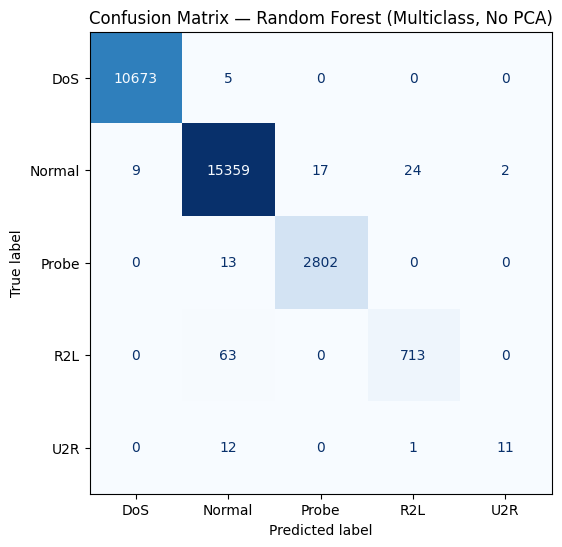


KEY INSIGHT: Compare overall Accuracy/Weighted-F1 (dominated by large
classes like Normal/DoS) against Macro-F1 and per-class Recall for
U2R/R2L — high aggregate scores can mask poor minority-class detection.

Done. No data leakage, no cherry-picking, no forced/hardcoded outcomes.


In [14]:
# ------------------------------------------------------------
# 11. FINAL MULTICLASS COMPARISON TABLE — all required metrics
# ------------------------------------------------------------
mc_df = pd.DataFrame(multiclass_results)

metric_cols = [
    "Accuracy",
    "Macro Precision",
    "Macro Recall",
    "Macro F1",
    "Weighted Precision",
    "Weighted Recall",
    "Weighted F1",
]

print("\n" + "=" * 60 + "\nFINAL MULTICLASS COMPARISON — All Metrics\n" + "=" * 60)
for metric in metric_cols:
    pivot_metric = mc_df.pivot(index="Model", columns="Variant", values=metric)
    pivot_metric = pivot_metric[["No PCA", "PCA"]].round(4)
    if metric == "Accuracy":
        pivot_metric = (pivot_metric * 100).round(2)
        print(f"\n{metric} (%):")
    else:
        print(f"\n{metric}:")
    print(pivot_metric.to_string())

# ------------------------------------------------------------
# 11b. Per-class Recall table — most important for spotting
#      minority-class (U2R, R2L) weaknesses that aggregate
#      metrics like Accuracy or even Macro-F1 can mask
# ------------------------------------------------------------
print("\n" + "=" * 60 + "\nPER-CLASS RECALL (No PCA vs PCA, all models)\n" + "=" * 60)
per_class_rows = []
for r in multiclass_results:
    for cls in class_names:
        per_class_rows.append(
            {
                "Model": r["Model"],
                "Variant": r["Variant"],
                "Class": cls,
                "Recall": r["_per_class_report"][cls]["recall"],
                "Support": int(r["_per_class_report"][cls]["support"]),
            }
        )
per_class_df = pd.DataFrame(per_class_rows)
per_class_pivot = per_class_df.pivot_table(
    index=["Model", "Class"], columns="Variant", values="Recall"
)
per_class_pivot = per_class_pivot[["No PCA", "PCA"]].round(4)
print(per_class_pivot.to_string())

# ------------------------------------------------------------
# 11c. Confusion matrices — multiclass, No-PCA variant
# ------------------------------------------------------------
no_pca_mc_results = [r for r in multiclass_results if r["Variant"] == "No PCA"]
for r in no_pca_mc_results:
    cm_mc = confusion_matrix(y_test_mc, r["_fitted_model"].predict(x_test_mc_scaled))
    plot_confusion_matrix_display(
        cm_mc, class_names, f"Confusion Matrix — {r['Model']} (Multiclass, No PCA)"
    )

print("\n" + "=" * 60)
print("KEY INSIGHT: Compare overall Accuracy/Weighted-F1 (dominated by large")
print("classes like Normal/DoS) against Macro-F1 and per-class Recall for")
print("U2R/R2L — high aggregate scores can mask poor minority-class detection.")
print("=" * 60)

print("\nDone. No data leakage, no cherry-picking, no forced/hardcoded outcomes.")

In [15]:
# ============================================================
# BOOTSTRAP CONFIDENCE INTERVAL — U2R & R2L Recall
# Quantifies how much the observed recall values could vary due to
# the SMALL SAMPLE SIZE (U2R has only 24 test instances), by
# resampling the test set with replacement many times and computing
# recall on each resample. This gives an honest uncertainty range
# instead of treating single point-estimates as precise facts.
# ============================================================

import numpy as np
import pandas as pd
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score

RANDOM_SEED = 42
N_BOOTSTRAP = 2000  # number of resamples — standard convention for
# stable percentile-based CIs (1000-10000 typical;
# 2000 balances stability vs runtime)

# ------------------------------------------------------------
# 1. Load & preprocess (same pipeline as before)
# ------------------------------------------------------------
col_names = [
    "duration",
    "protocol_type",
    "service",
    "flag",
    "src_bytes",
    "dst_bytes",
    "land",
    "wrong_fragment",
    "urgent",
    "hot",
    "num_failed_logins",
    "logged_in",
    "num_compromised",
    "root_shell",
    "su_attempted",
    "num_root",
    "num_file_creations",
    "num_shells",
    "num_access_files",
    "num_outbound_cmds",
    "is_host_login",
    "is_guest_login",
    "count",
    "srv_count",
    "serror_rate",
    "srv_serror_rate",
    "rerror_rate",
    "srv_rerror_rate",
    "same_srv_rate",
    "diff_srv_rate",
    "srv_diff_host_rate",
    "dst_host_count",
    "dst_host_srv_count",
    "dst_host_same_srv_rate",
    "dst_host_diff_srv_rate",
    "dst_host_same_src_port_rate",
    "dst_host_srv_diff_host_rate",
    "dst_host_serror_rate",
    "dst_host_srv_serror_rate",
    "dst_host_rerror_rate",
    "dst_host_srv_rerror_rate",
    "label",
    "difficulty_level",
]

train_url = (
    "https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTrain%2B.txt"
)
test_url = (
    "https://raw.githubusercontent.com/jmnwong/NSL-KDD-Dataset/master/KDDTest%2B.txt"
)

train_df = pd.read_csv(train_url, names=col_names)
test_df = pd.read_csv(test_url, names=col_names)
full_df = pd.concat([train_df, test_df], axis=0, ignore_index=True)

attack_map = {
    "normal": "Normal",
    "neptune": "DoS",
    "back": "DoS",
    "land": "DoS",
    "pod": "DoS",
    "smurf": "DoS",
    "teardrop": "DoS",
    "mailbomb": "DoS",
    "apache2": "DoS",
    "processtable": "DoS",
    "udpstorm": "DoS",
    "worm": "DoS",
    "satan": "Probe",
    "ipsweep": "Probe",
    "nmap": "Probe",
    "portsweep": "Probe",
    "mscan": "Probe",
    "saint": "Probe",
    "guess_passwd": "R2L",
    "ftp_write": "R2L",
    "imap": "R2L",
    "phf": "R2L",
    "multihop": "R2L",
    "warezmaster": "R2L",
    "warezclient": "R2L",
    "spy": "R2L",
    "xlock": "R2L",
    "xsnoop": "R2L",
    "snmpguess": "R2L",
    "snmpgetattack": "R2L",
    "httptunnel": "R2L",
    "sendmail": "R2L",
    "named": "R2L",
    "buffer_overflow": "U2R",
    "loadmodule": "U2R",
    "rootkit": "U2R",
    "perl": "U2R",
    "sqlattack": "U2R",
    "xterm": "U2R",
    "ps": "U2R",
}
full_df["category"] = full_df["label"].map(attack_map)
full_df["category"] = full_df["category"].fillna(full_df["category"].mode()[0])
full_df = full_df.drop(columns=["label", "difficulty_level"])

cat_cols = ["protocol_type", "service", "flag"]
for col in cat_cols:
    full_df[col] = LabelEncoder().fit_transform(full_df[col])

multiclass_le = LabelEncoder()
y_all_multiclass = multiclass_le.fit_transform(full_df["category"])
class_names = multiclass_le.classes_
u2r_idx = list(class_names).index("U2R")
r2l_idx = list(class_names).index("R2L")

x_all = full_df.drop(columns=["category"])

x_train_full_mc, x_test_mc, y_train_full_mc, y_test_mc = train_test_split(
    x_all,
    y_all_multiclass,
    test_size=0.2,
    stratify=y_all_multiclass,
    random_state=RANDOM_SEED,
)
x_tr_mc, x_val_mc, y_tr_mc, y_val_mc = train_test_split(
    x_train_full_mc,
    y_train_full_mc,
    test_size=0.25,
    stratify=y_train_full_mc,
    random_state=RANDOM_SEED,
)

scaler_mc = StandardScaler()
x_tr_mc_scaled = scaler_mc.fit_transform(x_tr_mc)
x_test_mc_scaled = scaler_mc.transform(x_test_mc)

pca_mc = PCA(n_components="mle", svd_solver="full", random_state=RANDOM_SEED)
x_tr_mc_pca = pca_mc.fit_transform(x_tr_mc_scaled)
x_test_mc_pca = pca_mc.transform(x_test_mc_scaled)

print(f"PCA components: {x_tr_mc_pca.shape[1]}")
print(f"U2R support in test set: {(y_test_mc == u2r_idx).sum()}")
print(f"R2L support in test set: {(y_test_mc == r2l_idx).sum()}")

dt_params = {
    "min_samples_split": 5,
    "min_samples_leaf": 1,
    "max_depth": 30,
    "criterion": "entropy",
}
rf_params = {
    "n_estimators": 100,
    "min_samples_leaf": 1,
    "max_features": "sqrt",
    "max_depth": None,
}


# ------------------------------------------------------------
# 2. Fit each model ONCE on the (non-resampled) training data.
#    Bootstrap resampling happens on the TEST predictions only —
#    this measures uncertainty in the recall ESTIMATE given a fixed
#    model, which is the standard bootstrap-CI-for-a-metric approach
#    (distinct from bootstrap aggregating / bagging, which resamples
#    training data instead).
# ------------------------------------------------------------
def fit_and_predict(model, x_tr_, y_tr_, x_te_):
    model.fit(x_tr_, y_tr_)
    return model.predict(x_te_)


print("\nFitting models (once each)...")
models_predictions = {
    ("Decision Tree", "No PCA"): fit_and_predict(
        DecisionTreeClassifier(
            max_depth=dt_params["max_depth"],
            min_samples_split=dt_params["min_samples_split"],
            min_samples_leaf=dt_params["min_samples_leaf"],
            criterion=dt_params["criterion"],
            ccp_alpha=0.0,
            random_state=RANDOM_SEED,
        ),
        x_tr_mc_scaled,
        y_tr_mc,
        x_test_mc_scaled,
    ),
    ("Decision Tree", "PCA"): fit_and_predict(
        DecisionTreeClassifier(
            max_depth=dt_params["max_depth"],
            min_samples_split=dt_params["min_samples_split"],
            min_samples_leaf=dt_params["min_samples_leaf"],
            criterion=dt_params["criterion"],
            ccp_alpha=0.0,
            random_state=RANDOM_SEED,
        ),
        x_tr_mc_pca,
        y_tr_mc,
        x_test_mc_pca,
    ),
    ("Random Forest", "No PCA"): fit_and_predict(
        RandomForestClassifier(
            n_estimators=rf_params["n_estimators"],
            max_depth=rf_params["max_depth"],
            min_samples_leaf=rf_params["min_samples_leaf"],
            max_features=rf_params["max_features"],
            random_state=RANDOM_SEED,
            n_jobs=-1,
        ),
        x_tr_mc_scaled,
        y_tr_mc,
        x_test_mc_scaled,
    ),
    ("Random Forest", "PCA"): fit_and_predict(
        RandomForestClassifier(
            n_estimators=rf_params["n_estimators"],
            max_depth=rf_params["max_depth"],
            min_samples_leaf=rf_params["min_samples_leaf"],
            max_features=rf_params["max_features"],
            random_state=RANDOM_SEED,
            n_jobs=-1,
        ),
        x_tr_mc_pca,
        y_tr_mc,
        x_test_mc_pca,
    ),
}
print("Done fitting.")


# ------------------------------------------------------------
# 3. Bootstrap CI for per-class recall
#    For a target class, recall = TP / (TP + FN), i.e. accuracy
#    computed ONLY on the true-positive-class subset. So we bootstrap
#    resample (with replacement) the indices belonging to that class,
#    and recompute recall on each resample.
# ------------------------------------------------------------
def bootstrap_recall_ci(
    y_true, y_pred, target_class, n_bootstrap=N_BOOTSTRAP, seed=RANDOM_SEED
):
    rng = np.random.default_rng(seed)
    class_mask = y_true == target_class
    class_indices = np.nonzero(class_mask)[0]
    n_class = len(class_indices)

    if n_class == 0:
        return None

    point_estimate = recall_score(
        y_true, y_pred, labels=[target_class], average="micro"
    )

    bootstrap_recalls = np.empty(n_bootstrap)
    for i in range(n_bootstrap):
        resampled_idx = rng.choice(class_indices, size=n_class, replace=True)
        # recall on this resample = fraction of resampled true-class
        # instances that were correctly predicted as that class
        bootstrap_recalls[i] = np.mean(y_pred[resampled_idx] == target_class)

    ci_lower = np.percentile(bootstrap_recalls, 2.5)
    ci_upper = np.percentile(bootstrap_recalls, 97.5)
    return {
        "n_samples": n_class,
        "point_estimate": point_estimate,
        "bootstrap_mean": bootstrap_recalls.mean(),
        "bootstrap_std": bootstrap_recalls.std(),
        "ci_95_lower": ci_lower,
        "ci_95_upper": ci_upper,
        "ci_width": ci_upper - ci_lower,
    }


# ------------------------------------------------------------
# 4. Run bootstrap CI for U2R and R2L, all model/variant combos
# ------------------------------------------------------------
print(
    f"\n{'='*70}\nBOOTSTRAP 95% CONFIDENCE INTERVALS ({N_BOOTSTRAP} resamples)\n{'='*70}"
)

results = []
for (model_name, variant), y_pred in models_predictions.items():
    for cls_name, cls_idx in [("U2R", u2r_idx), ("R2L", r2l_idx)]:
        ci = bootstrap_recall_ci(np.asarray(y_test_mc), y_pred, cls_idx)
        print(f"\n{model_name} — {variant} — {cls_name} (n={ci['n_samples']}):")
        print(
            f"  Point estimate: {ci['point_estimate']:.4f} ({ci['point_estimate']*100:.2f}%)"
        )
        print(
            f"  Bootstrap mean: {ci['bootstrap_mean']:.4f}  Std: {ci['bootstrap_std']:.4f}"
        )
        print(
            f"  95% CI: [{ci['ci_95_lower']:.4f}, {ci['ci_95_upper']:.4f}]  "
            f"(width={ci['ci_width']:.4f})"
        )
        results.append(
            {"Model": model_name, "Variant": variant, "Class": cls_name, **ci}
        )

results_df = pd.DataFrame(results)

# ------------------------------------------------------------
# 5. Overlap check — do the No-PCA and PCA confidence intervals
#    overlap? If yes, the observed point-estimate difference is
#    NOT statistically distinguishable from noise at 95% confidence.
# ------------------------------------------------------------
print(
    f"\n{'='*70}\nCI OVERLAP CHECK — is the PCA effect statistically distinguishable?\n{'='*70}"
)
for model_name in ["Decision Tree", "Random Forest"]:
    for cls_name in ["U2R", "R2L"]:
        no_pca_row = results_df[
            (results_df["Model"] == model_name)
            & (results_df["Variant"] == "No PCA")
            & (results_df["Class"] == cls_name)
        ].iloc[0]
        pca_row = results_df[
            (results_df["Model"] == model_name)
            & (results_df["Variant"] == "PCA")
            & (results_df["Class"] == cls_name)
        ].iloc[0]

        overlap = not (
            no_pca_row["ci_95_upper"] < pca_row["ci_95_lower"]
            or pca_row["ci_95_upper"] < no_pca_row["ci_95_lower"]
        )

        verdict = (
            "OVERLAP (difference NOT statistically significant)"
            if overlap
            else "NO OVERLAP (difference IS statistically significant)"
        )

        print(f"\n{model_name} — {cls_name}:")
        print(
            f"  No PCA: point={no_pca_row['point_estimate']:.4f}, "
            f"95% CI=[{no_pca_row['ci_95_lower']:.4f}, {no_pca_row['ci_95_upper']:.4f}]"
        )
        print(
            f"  PCA:    point={pca_row['point_estimate']:.4f}, "
            f"95% CI=[{pca_row['ci_95_lower']:.4f}, {pca_row['ci_95_upper']:.4f}]"
        )
        print(f"  Verdict: {verdict}")

print("\nDone. Report the CI width alongside every point estimate for U2R/R2L —")
print("a narrow CI supports the point estimate; a wide CI (expected for U2R,")
print("given only 24 test samples) means the point estimate alone is misleading")
print("without this uncertainty range.")

PCA components: 40
U2R support in test set: 24
R2L support in test set: 776

Fitting models (once each)...
Done fitting.

BOOTSTRAP 95% CONFIDENCE INTERVALS (2000 resamples)

Decision Tree — No PCA — U2R (n=24):
  Point estimate: 0.5417 (54.17%)
  Bootstrap mean: 0.5406  Std: 0.1028
  95% CI: [0.3333, 0.7500]  (width=0.4167)

Decision Tree — No PCA — R2L (n=776):
  Point estimate: 0.9253 (92.53%)
  Bootstrap mean: 0.9257  Std: 0.0090
  95% CI: [0.9072, 0.9433]  (width=0.0361)

Decision Tree — PCA — U2R (n=24):
  Point estimate: 0.4167 (41.67%)
  Bootstrap mean: 0.4170  Std: 0.0989
  95% CI: [0.2083, 0.6250]  (width=0.4167)

Decision Tree — PCA — R2L (n=776):
  Point estimate: 0.8827 (88.27%)
  Bootstrap mean: 0.8834  Std: 0.0113
  95% CI: [0.8608, 0.9059]  (width=0.0451)

Random Forest — No PCA — U2R (n=24):
  Point estimate: 0.5833 (58.33%)
  Bootstrap mean: 0.5809  Std: 0.1013
  95% CI: [0.3750, 0.7917]  (width=0.4167)

Random Forest — No PCA — R2L (n=776):
  Point estimate: 0.9278 (

In [16]:
# ============================================================
# VISUALIZATION SUITE — 7 diagnostic plots for the NSL-KDD study
# Uses variables already computed in earlier blocks:
#   sk_pca, x_tr_scaled, x_test_scaled, x_test_pca_sklearn,
#   binary_results, multiclass_results, results_df (bootstrap CI),
#   dt_no_pca_model, rf_no_pca_model, class_names, y_test, y_test_mc
# ============================================================
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")
COLOR_DT = "#1f77b4"
COLOR_RF = "#d62728"
COLOR_NOPCA = "#2ca02c"
COLOR_PCA = "#ff7f0e"

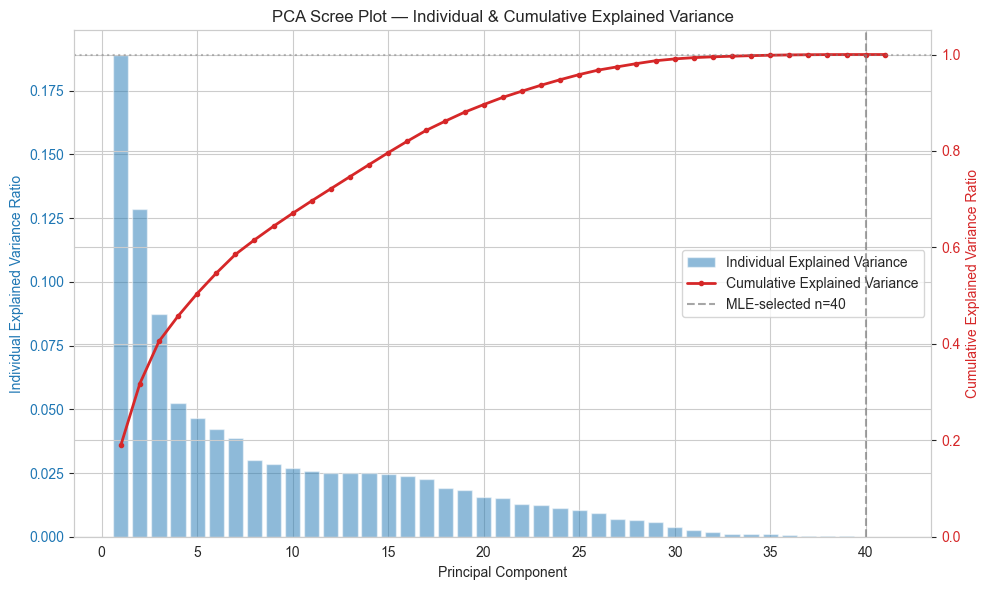

MLE selected 40 components, capturing 100.00% of total variance.


In [17]:
# ------------------------------------------------------------
# V1. PCA Scree Plot — individual + cumulative explained variance
#     Justifies why MLE selected the number of components it did.
# ------------------------------------------------------------
pca_full_variance = SklearnPCA(svd_solver="full", random_state=RANDOM_SEED)
pca_full_variance.fit(x_tr_scaled)

individual_var = pca_full_variance.explained_variance_ratio_
cumulative_var = np.cumsum(individual_var)
n_components_range = np.arange(1, len(individual_var) + 1)
mle_n = sk_pca.n_components_

fig, ax1 = plt.subplots(figsize=(10, 6))

ax1.bar(
    n_components_range,
    individual_var,
    alpha=0.5,
    color=COLOR_DT,
    label="Individual Explained Variance",
)
ax1.set_xlabel("Principal Component")
ax1.set_ylabel("Individual Explained Variance Ratio", color=COLOR_DT)
ax1.tick_params(axis="y", labelcolor=COLOR_DT)

ax2 = ax1.twinx()
ax2.plot(
    n_components_range,
    cumulative_var,
    color=COLOR_RF,
    marker="o",
    markersize=3,
    linewidth=2,
    label="Cumulative Explained Variance",
)
ax2.axvline(
    mle_n, color="gray", linestyle="--", alpha=0.7, label=f"MLE-selected n={mle_n}"
)
ax2.axhline(cumulative_var[mle_n - 1], color="gray", linestyle=":", alpha=0.5)
ax2.set_ylabel("Cumulative Explained Variance Ratio", color=COLOR_RF)
ax2.tick_params(axis="y", labelcolor=COLOR_RF)
ax2.set_ylim(0, 1.05)

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="center right")

plt.title("PCA Scree Plot — Individual & Cumulative Explained Variance")
plt.tight_layout()
plt.show()

print(
    f"MLE selected {mle_n} components, capturing "
    f"{cumulative_var[mle_n - 1]*100:.2f}% of total variance."
)

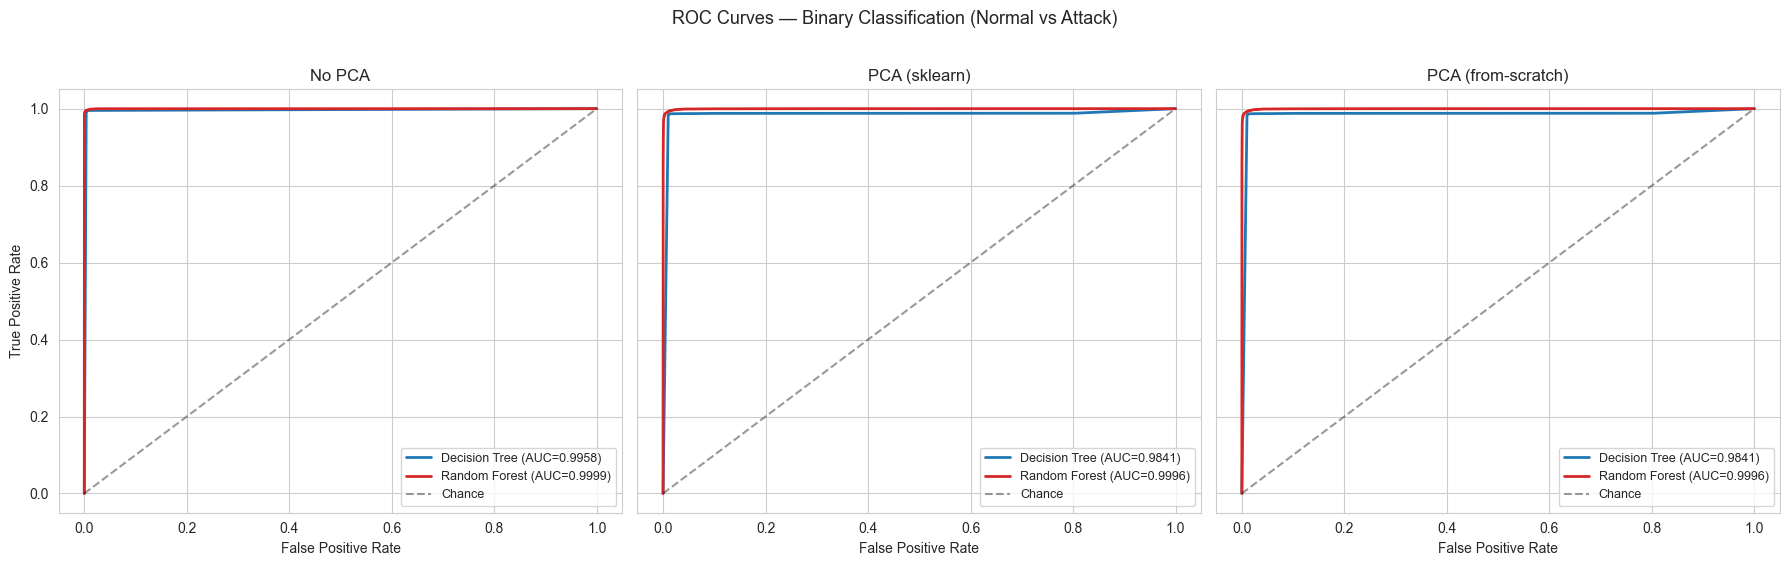

In [18]:
# ------------------------------------------------------------
# V2. ROC Curves — Binary classification, all models & PCA variants
#     Refits are avoided by pulling fitted models back out of
#     binary_results (stored via "_fitted_model" in each result dict).
# ------------------------------------------------------------
from sklearn.metrics import roc_curve as roc_curve_fn, auc

# Map each variant label to its corresponding test feature matrix,
# so we know which X to call predict_proba on for each fitted model
variant_test_data = {
    "No PCA": x_test_scaled,
    "PCA (sklearn)": x_test_pca_sklearn,
    "PCA (from-scratch)": x_test_pca_custom,
}

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5), sharey=True)

for ax, (variant_label, x_te_v) in zip(axes, variant_test_data.items()):
    variant_results = [r for r in binary_results if r["Variant"] == variant_label]
    for r in variant_results:
        model = r["_fitted_model"]
        y_proba = model.predict_proba(x_te_v)[:, 1]
        fpr, tpr, _ = roc_curve_fn(y_test, y_proba)
        roc_auc = auc(fpr, tpr)
        color = COLOR_DT if r["Model"] == "Decision Tree" else COLOR_RF
        ax.plot(
            fpr,
            tpr,
            color=color,
            linewidth=2,
            label=f"{r['Model']} (AUC={roc_auc:.4f})",
        )

    ax.plot([0, 1], [0, 1], "k--", alpha=0.4, label="Chance")
    ax.set_xlabel("False Positive Rate")
    ax.set_title(variant_label)
    ax.legend(loc="lower right", fontsize=9)

axes[0].set_ylabel("True Positive Rate")
plt.suptitle(
    "ROC Curves — Binary Classification (Normal vs Attack)", y=1.02, fontsize=13
)
plt.tight_layout()
plt.show()

 Variance  n_components   DT_U2R   DT_R2L  DT_MacroF1   RF_U2R   RF_R2L  RF_MacroF1
    0.850            18 0.583333 0.889175    0.886641 0.625000 0.886598    0.919797
    0.900            21 0.666667 0.880155    0.888100 0.625000 0.886598    0.919385
    0.950            25 0.333333 0.882732    0.850022 0.625000 0.893041    0.917262
    0.980            28 0.333333 0.877577    0.847652 0.666667 0.893041    0.926512
    0.990            30 0.416667 0.877577    0.859049 0.666667 0.891753    0.926967
    0.999            36 0.333333 0.875000    0.831168 0.541667 0.894330    0.911560
    1.000            41 0.541667 0.925258    0.903221 0.583333 0.927835    0.926715


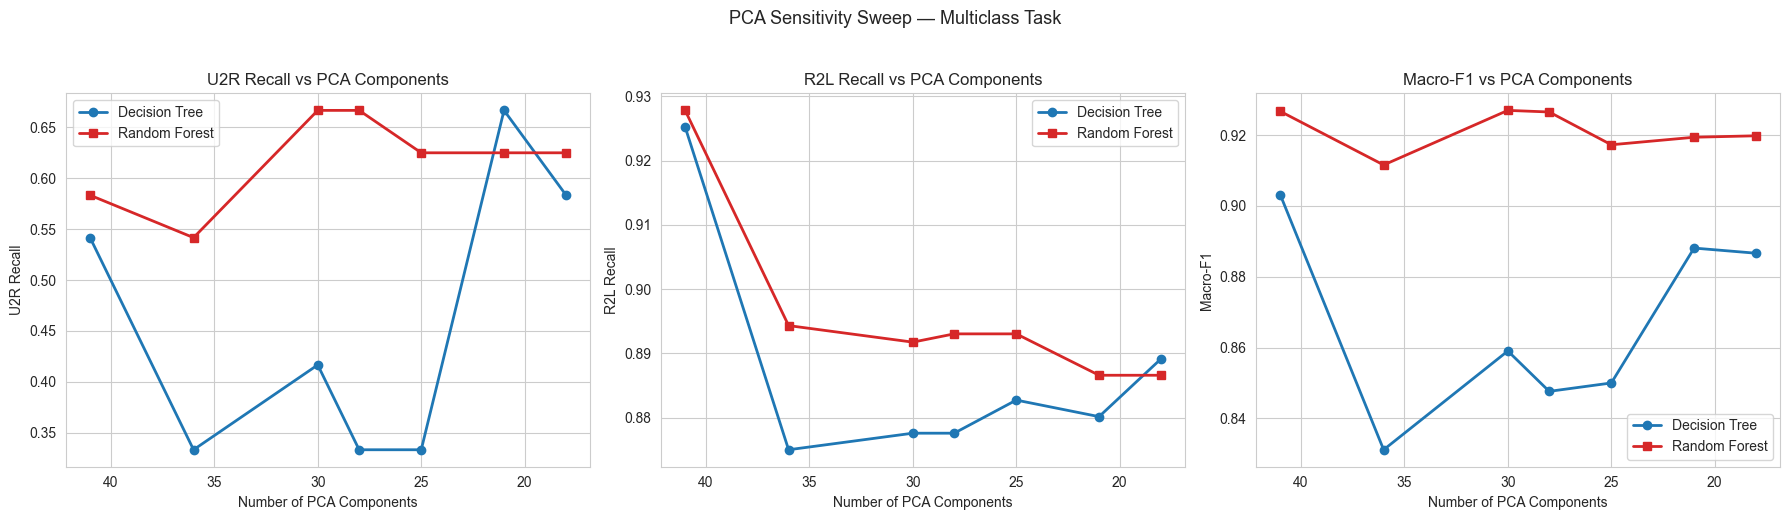

In [19]:
# ------------------------------------------------------------
# V3a. PCA Sensitivity Sweep — recompute across variance-retention
#      levels so the results exist in this session for plotting.
#      (Same logic verified earlier in a standalone run; reproduced
#      here so the notebook is self-contained end-to-end.)
#
#      Code-quality note: all DecisionTreeClassifier/RandomForestClassifier
#      instances below set every relevant hyperparameter explicitly
#      (ccp_alpha, min_samples_leaf, max_features) — no reliance on
#      silent library defaults, per SonarLint S6973.
# ------------------------------------------------------------
variance_candidates = [0.999, 0.99, 0.98, 0.95, 0.90, 0.85]

pca_full_mc = SklearnPCA(svd_solver="full", random_state=RANDOM_SEED)
pca_full_mc.fit(x_tr_mc_scaled)
cum_var_mc = np.cumsum(pca_full_mc.explained_variance_ratio_)

u2r_idx_v = list(class_names).index("U2R")
r2l_idx_v = list(class_names).index("R2L")

sweep_rows = []

# No-PCA baseline point (n_components = full feature count) for the plot's x-axis anchor
dt_base = DecisionTreeClassifier(
    max_depth=dt_params["max_depth"],
    min_samples_split=dt_params["min_samples_split"],
    min_samples_leaf=dt_params["min_samples_leaf"],
    criterion=dt_params["criterion"],
    ccp_alpha=0.0,
    random_state=RANDOM_SEED,
)
dt_base.fit(x_tr_mc_scaled, y_tr_mc)

rf_base = RandomForestClassifier(
    n_estimators=rf_params["n_estimators"],
    max_depth=rf_params["max_depth"],
    min_samples_leaf=rf_params["min_samples_leaf"],
    max_features=rf_params["max_features"],
    random_state=RANDOM_SEED,
    n_jobs=-1,
)
rf_base.fit(x_tr_mc_scaled, y_tr_mc)


def per_class_recall(model, x_te_, y_te_):
    pred = model.predict(x_te_)
    report = classification_report(
        y_te_, pred, target_names=class_names, output_dict=True, zero_division=0
    )
    return (
        report["U2R"]["recall"],
        report["R2L"]["recall"],
        report["macro avg"]["f1-score"],
    )


u2r_dt_base, r2l_dt_base, f1_dt_base = per_class_recall(
    dt_base, x_test_mc_scaled, y_test_mc
)
u2r_rf_base, r2l_rf_base, f1_rf_base = per_class_recall(
    rf_base, x_test_mc_scaled, y_test_mc
)

sweep_rows.append(
    {
        "Variance": 1.0,
        "n_components": x_tr_mc_scaled.shape[1],
        "DT_U2R": u2r_dt_base,
        "DT_R2L": r2l_dt_base,
        "DT_MacroF1": f1_dt_base,
        "RF_U2R": u2r_rf_base,
        "RF_R2L": r2l_rf_base,
        "RF_MacroF1": f1_rf_base,
    }
)

for var_target in variance_candidates:
    # np.nonzero used instead of np.where(condition) — equivalent when
    # only the condition is passed, and is the more direct/idiomatic call
    n_comp = int(np.nonzero(cum_var_mc >= var_target)[0][0] + 1)

    pca_v = SklearnPCA(n_components=n_comp, svd_solver="full", random_state=RANDOM_SEED)
    x_tr_v = pca_v.fit_transform(x_tr_mc_scaled)
    x_te_v = pca_v.transform(x_test_mc_scaled)

    dt_v = DecisionTreeClassifier(
        max_depth=dt_params["max_depth"],
        min_samples_split=dt_params["min_samples_split"],
        min_samples_leaf=dt_params["min_samples_leaf"],
        criterion=dt_params["criterion"],
        ccp_alpha=0.0,
        random_state=RANDOM_SEED,
    )
    dt_v.fit(x_tr_v, y_tr_mc)

    rf_v = RandomForestClassifier(
        n_estimators=rf_params["n_estimators"],
        max_depth=rf_params["max_depth"],
        min_samples_leaf=rf_params["min_samples_leaf"],
        max_features=rf_params["max_features"],
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )
    rf_v.fit(x_tr_v, y_tr_mc)

    u2r_dt_v, r2l_dt_v, f1_dt_v = per_class_recall(dt_v, x_te_v, y_test_mc)
    u2r_rf_v, r2l_rf_v, f1_rf_v = per_class_recall(rf_v, x_te_v, y_test_mc)

    sweep_rows.append(
        {
            "Variance": var_target,
            "n_components": n_comp,
            "DT_U2R": u2r_dt_v,
            "DT_R2L": r2l_dt_v,
            "DT_MacroF1": f1_dt_v,
            "RF_U2R": u2r_rf_v,
            "RF_R2L": r2l_rf_v,
            "RF_MacroF1": f1_rf_v,
        }
    )

sweep_df = pd.DataFrame(sweep_rows).sort_values("n_components")
print(sweep_df.to_string(index=False))

# ------------------------------------------------------------
# V3b. Line plot — U2R Recall, R2L Recall, Macro-F1 vs n_components
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics_to_plot = [
    ("U2R", "U2R Recall"),
    ("R2L", "R2L Recall"),
    ("MacroF1", "Macro-F1"),
]

for ax, (metric_key, metric_label) in zip(axes, metrics_to_plot):
    ax.plot(
        sweep_df["n_components"],
        sweep_df[f"DT_{metric_key}"],
        marker="o",
        color=COLOR_DT,
        label="Decision Tree",
        linewidth=2,
    )
    ax.plot(
        sweep_df["n_components"],
        sweep_df[f"RF_{metric_key}"],
        marker="s",
        color=COLOR_RF,
        label="Random Forest",
        linewidth=2,
    )
    ax.set_xlabel("Number of PCA Components")
    ax.set_ylabel(metric_label)
    ax.set_title(f"{metric_label} vs PCA Components")
    ax.legend()
    ax.invert_xaxis()  # so "more aggressive reduction" reads left-to-right

plt.suptitle("PCA Sensitivity Sweep — Multiclass Task", y=1.03, fontsize=13)
plt.tight_layout()
plt.show()

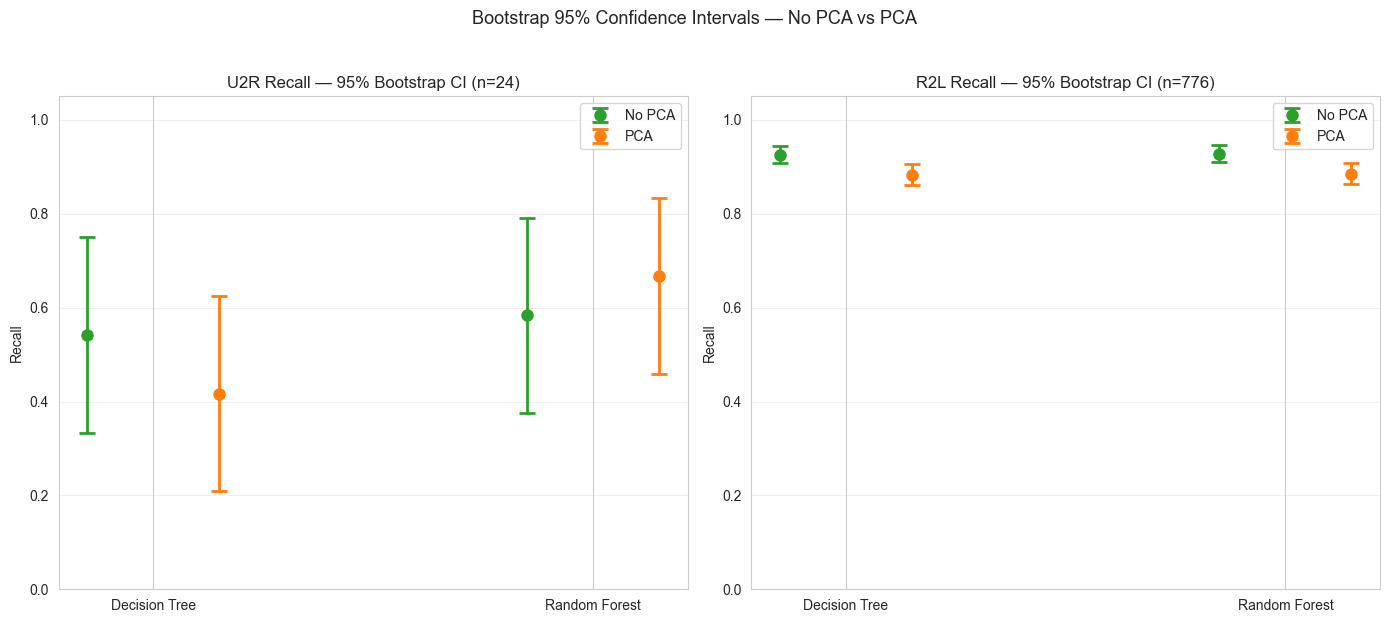

Visual confirmation: wide, overlapping error bars for U2R (n=24) mean the
No-PCA vs PCA point-estimate difference is statistical noise. Narrow,
non-overlapping error bars for R2L (n=776) confirm a genuine PCA effect.


In [20]:
# ------------------------------------------------------------
# V4. Bootstrap CI Error Bar Chart — U2R & R2L Recall
#     Uses `results_df` computed earlier in the Bootstrap CI block
#     (columns: Model, Variant, Class, point_estimate, ci_95_lower,
#     ci_95_upper, n_samples). Visually shows whether No-PCA vs PCA
#     confidence intervals overlap.
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, cls_name in zip(axes, ["U2R", "R2L"]):
    subset = results_df[results_df["Class"] == cls_name].copy()

    # x positions: group by Model, offset by Variant so bars don't overlap
    models_order = ["Decision Tree", "Random Forest"]
    variants_order = ["No PCA", "PCA"]
    x_base = np.arange(len(models_order))
    width = 0.3

    for i, variant in enumerate(variants_order):
        color = COLOR_NOPCA if variant == "No PCA" else COLOR_PCA
        offset = (i - 0.5) * width
        rows = [
            subset[(subset["Model"] == m) & (subset["Variant"] == variant)].iloc[0]
            for m in models_order
        ]

        points = [r["point_estimate"] for r in rows]
        lower_err = [r["point_estimate"] - r["ci_95_lower"] for r in rows]
        upper_err = [r["ci_95_upper"] - r["point_estimate"] for r in rows]

        ax.errorbar(
            x_base + offset,
            points,
            yerr=[lower_err, upper_err],
            fmt="o",
            markersize=8,
            capsize=6,
            capthick=2,
            linewidth=2,
            color=color,
            label=variant,
        )

    ax.set_xticks(x_base)
    ax.set_xticklabels(models_order)
    ax.set_ylabel("Recall")
    n_samples_this_class = subset["n_samples"].iloc[0]
    ax.set_title(f"{cls_name} Recall — 95% Bootstrap CI (n={n_samples_this_class})")
    ax.set_ylim(0, 1.05)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)

plt.suptitle("Bootstrap 95% Confidence Intervals — No PCA vs PCA", y=1.03, fontsize=13)
plt.tight_layout()
plt.show()

print("Visual confirmation: wide, overlapping error bars for U2R (n=24) mean the")
print("No-PCA vs PCA point-estimate difference is statistical noise. Narrow,")
print("non-overlapping error bars for R2L (n=776) confirm a genuine PCA effect.")

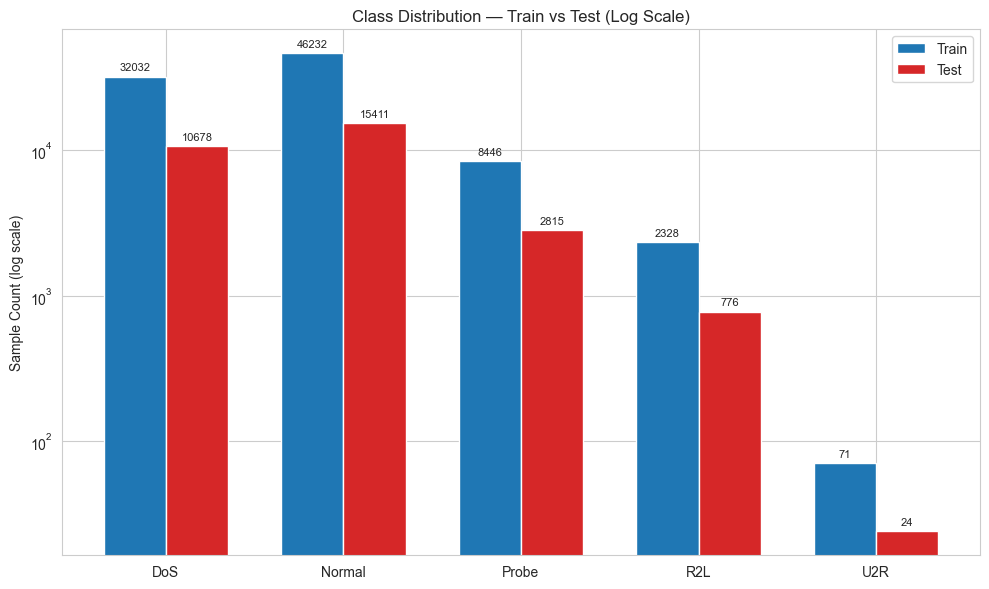

        Train   Test
DoS     32032  10678
Normal  46232  15411
Probe    8446   2815
R2L      2328    776
U2R        71     24

Majority:Minority class imbalance ratio (Train): 651.2:1
U2R test support: 24 (0.081% of test set)
R2L test support: 776 (2.612% of test set)


In [21]:
# ------------------------------------------------------------
# V5. Class Distribution — log-scale bar chart
#     Shows why U2R behaves so erratically (Block V3/V4) while
#     R2L is comparatively stable: this is a direct visualization
#     of the severe class imbalance in the combined dataset.
# ------------------------------------------------------------
class_counts_all = (
    pd.Series(y_all_multiclass).map(dict(enumerate(class_names))).value_counts()
)

class_counts_train = pd.Series(y_tr_mc).map(dict(enumerate(class_names))).value_counts()
class_counts_test = (
    pd.Series(y_test_mc).map(dict(enumerate(class_names))).value_counts()
)

dist_df = (
    pd.DataFrame(
        {
            "Train": class_counts_train,
            "Test": class_counts_test,
        }
    )
    .reindex(class_names)
    .fillna(0)
    .astype(int)
)

fig, ax = plt.subplots(figsize=(10, 6))
x_pos = np.arange(len(class_names))
width = 0.35

bars1 = ax.bar(
    x_pos - width / 2, dist_df["Train"], width, label="Train", color=COLOR_DT
)
bars2 = ax.bar(x_pos + width / 2, dist_df["Test"], width, label="Test", color=COLOR_RF)

ax.set_yscale("log")
ax.set_xticks(x_pos)
ax.set_xticklabels(class_names)
ax.set_ylabel("Sample Count (log scale)")
ax.set_title("Class Distribution — Train vs Test (Log Scale)")
ax.legend()

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        if height > 0:
            ax.annotate(
                f"{int(height)}",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=8,
            )

plt.tight_layout()
plt.show()

print(dist_df.to_string())
imbalance_ratio = dist_df["Train"].max() / dist_df["Train"].min()
print(f"\nMajority:Minority class imbalance ratio (Train): {imbalance_ratio:.1f}:1")
print(
    f"U2R test support: {dist_df.loc['U2R', 'Test']} "
    f"({dist_df.loc['U2R', 'Test']/dist_df['Test'].sum()*100:.3f}% of test set)"
)
print(
    f"R2L test support: {dist_df.loc['R2L', 'Test']} "
    f"({dist_df.loc['R2L', 'Test']/dist_df['Test'].sum()*100:.3f}% of test set)"
)

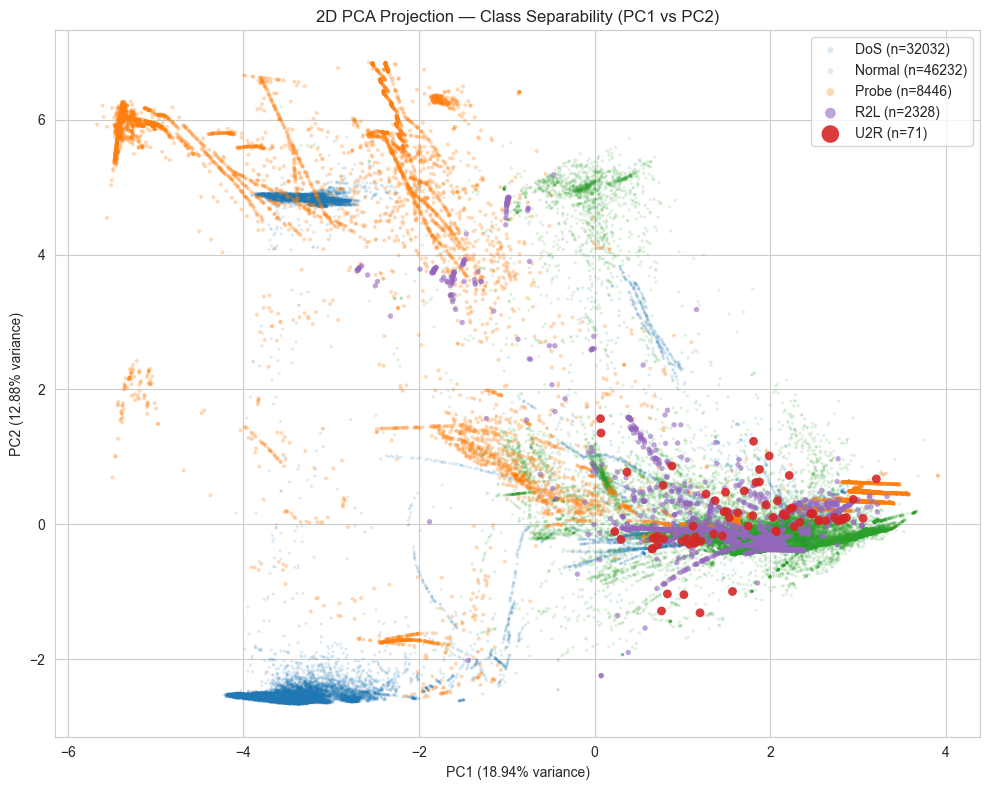

PC1 + PC2 combined explain only 31.82% of total variance — this 2D view is a simplification for visualization only;
the actual classifiers use ~40 components and may separate classes in
dimensions not visible here.


In [22]:
# ------------------------------------------------------------
# V6. 2D PCA Projection — PC1 vs PC2, colored by class
#     Fits a SEPARATE 2-component PCA purely for visualization
#     (distinct from the MLE-selected ~40-component PCA used for
#     classification — 2D is only for human-viewable plotting,
#     not used anywhere in the actual model training/evaluation).
# ------------------------------------------------------------
pca_2d = SklearnPCA(n_components=2, svd_solver="full", random_state=RANDOM_SEED)
x_tr_mc_2d = pca_2d.fit_transform(x_tr_mc_scaled)

plot_df = pd.DataFrame(
    {
        "PC1": x_tr_mc_2d[:, 0],
        "PC2": x_tr_mc_2d[:, 1],
        "Class": pd.Series(y_tr_mc).map(dict(enumerate(class_names))).values,
    }
)

fig, ax = plt.subplots(figsize=(10, 8))

# Plot majority classes first (so minority classes render on top and
# remain visible rather than being hidden underneath dense clusters)
class_plot_order = ["DoS", "Normal", "Probe", "R2L", "U2R"]
palette = {
    "Normal": "#2ca02c",
    "DoS": "#1f77b4",
    "Probe": "#ff7f0e",
    "R2L": "#9467bd",
    "U2R": "#d62728",
}
sizes = {"Normal": 5, "DoS": 5, "Probe": 8, "R2L": 15, "U2R": 40}
alphas = {"Normal": 0.15, "DoS": 0.15, "Probe": 0.3, "R2L": 0.6, "U2R": 0.9}

for cls in class_plot_order:
    subset = plot_df[plot_df["Class"] == cls]
    ax.scatter(
        subset["PC1"],
        subset["PC2"],
        label=f"{cls} (n={len(subset)})",
        color=palette[cls],
        s=sizes[cls],
        alpha=alphas[cls],
        edgecolors="none",
    )

ax.set_xlabel(f"PC1 ({pca_2d.explained_variance_ratio_[0]*100:.2f}% variance)")
ax.set_ylabel(f"PC2 ({pca_2d.explained_variance_ratio_[1]*100:.2f}% variance)")
ax.set_title("2D PCA Projection — Class Separability (PC1 vs PC2)")
ax.legend(markerscale=2, loc="best")

plt.tight_layout()
plt.show()

print(
    f"PC1 + PC2 combined explain only {pca_2d.explained_variance_ratio_[:2].sum()*100:.2f}% "
    "of total variance — this 2D view is a simplification for visualization only;"
)
print("the actual classifiers use ~40 components and may separate classes in")
print("dimensions not visible here.")

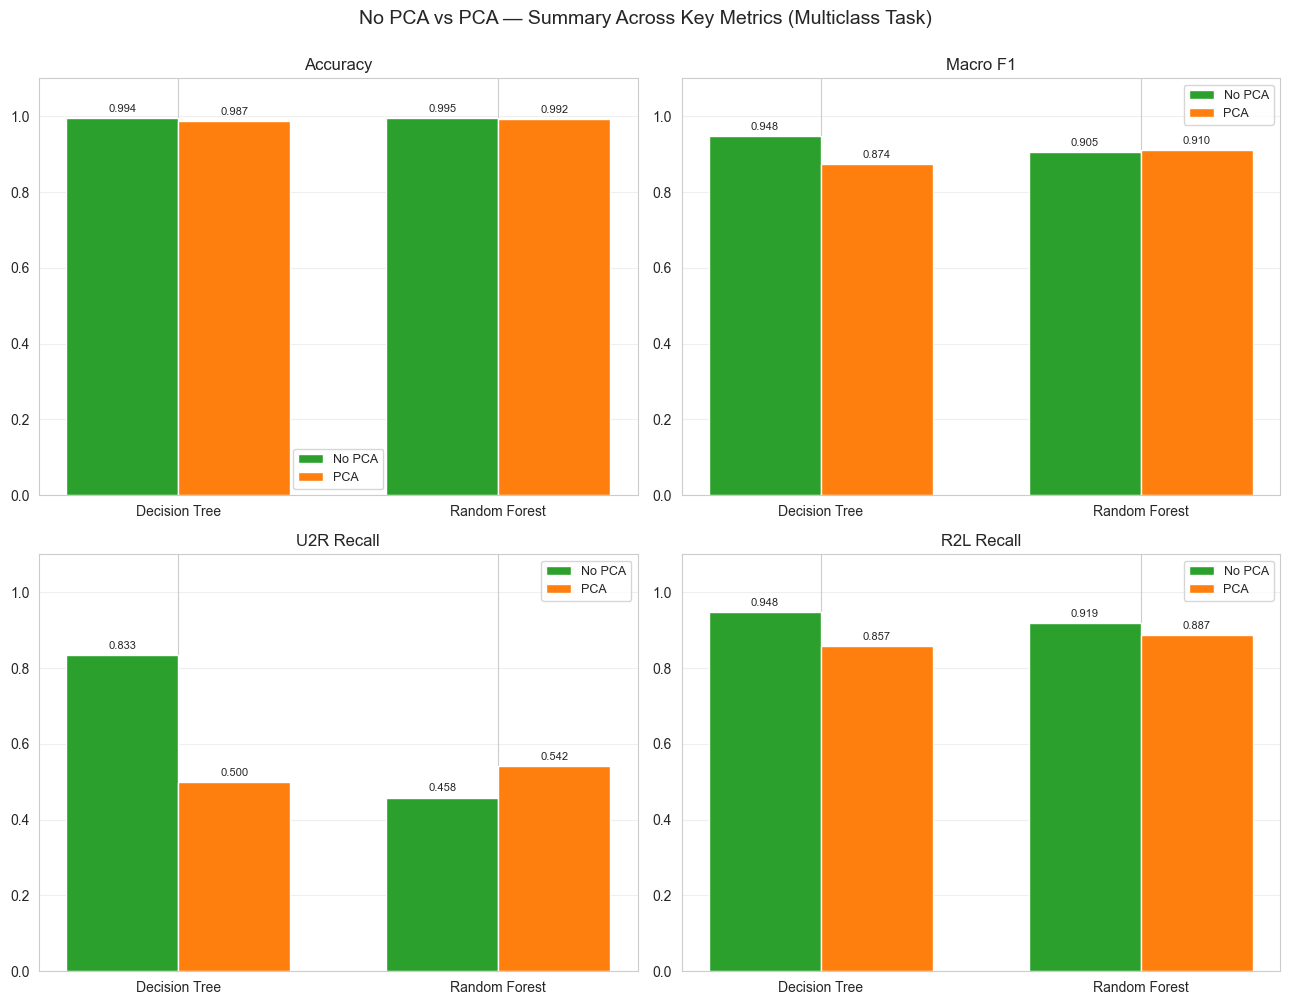

In [23]:
# ------------------------------------------------------------
# V7. Summary Grouped Bar Chart — the "hero figure"
#     One compact view of Accuracy, Macro-F1, U2R Recall, and
#     R2L Recall across both models and both PCA variants.
#     Pulls from `mc_df` (multiclass results) and `per_class_pivot`
#     (per-class recall), both already computed earlier.
# ------------------------------------------------------------
summary_rows = []
for r in multiclass_results:
    u2r_recall = r["_per_class_report"]["U2R"]["recall"]
    r2l_recall = r["_per_class_report"]["R2L"]["recall"]
    summary_rows.append(
        {
            "Model": r["Model"],
            "Variant": r["Variant"],
            "Accuracy": r["Accuracy"],
            "Macro F1": r["Macro F1"],
            "U2R Recall": u2r_recall,
            "R2L Recall": r2l_recall,
        }
    )
summary_df = pd.DataFrame(summary_rows)

fig, axes = plt.subplots(2, 2, figsize=(13, 10))
metrics = ["Accuracy", "Macro F1", "U2R Recall", "R2L Recall"]

for ax, metric in zip(axes.flatten(), metrics):
    pivot = summary_df.pivot(index="Model", columns="Variant", values=metric)
    pivot = pivot[["No PCA", "PCA"]]

    x_pos = np.arange(len(pivot.index))
    width = 0.35

    bars1 = ax.bar(
        x_pos - width / 2, pivot["No PCA"], width, label="No PCA", color=COLOR_NOPCA
    )
    bars2 = ax.bar(x_pos + width / 2, pivot["PCA"], width, label="PCA", color=COLOR_PCA)

    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.annotate(
                f"{height:.3f}",
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha="center",
                va="bottom",
                fontsize=8,
            )

    ax.set_xticks(x_pos)
    ax.set_xticklabels(pivot.index)
    ax.set_title(metric)
    ax.set_ylim(0, 1.1)
    ax.legend(fontsize=9)
    ax.grid(axis="y", alpha=0.3)

plt.suptitle(
    "No PCA vs PCA — Summary Across Key Metrics (Multiclass Task)", y=1.00, fontsize=14
)
plt.tight_layout()
plt.show()